In [136]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import response_processing as rp
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_200.json"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


## Load GT

In [137]:
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, Prediction_T1_2102 to Sequence_T4_2421
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          200 non-null    object 
 1   video_id          200 non-null    object 
 2   start             200 non-null    float64
 3   end               200 non-null    float64
 4   text              200 non-null    object 
 5   question_program  200 non-null    object 
 6   choices           200 non-null    object 
 7   situations        200 non-null    object 
dtypes: float64(2), object(6)
memory usage: 14.1+ KB


# Experiment 1

#### Comparison between Gemma3:4b and Gemini 2.5 flash on the Graph QA task on the STSG generated by Gemini 2.5 flash

In [138]:
GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_200_20250804_19:21:00.jsonl"
GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_on_geminiSGG_gemini2.5flash_20250804_21:49:00.jsonl" # TODO: 


In [139]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {  "answer": "Based on the provided Spatio-Temporal Scene Graph, the person does not close any object before holding a 'small_dark_object' (Frame 4) or a 'mobile_phone' (Frame 5). The 'upper_cabinet' door, which the person interacts with, is explicitly stated to be 'open' from Frame 3 until the end of the sequence (Frame 8). Therefore, none of the alternatives are supported by the given STSG as an action that occurred. Since I must choose one of the alternatives, and acknowledging the lack of evidence for any closing action, it is impossible to definitively select a correct answer from the given options based on the provided STSG. If forced to choose the "closest" related object, it would be the cabinet/door, but the ac

Total answers: 199
Answers following JSON template: 199
Percentage following JSON template: 100.00%
Answer with a valid alternative: 196
98.49% of the total

Invalid answers: 3
Total answers: 199
Answers following JSON template: 199
Percentage following JSON template: 100.00%
Answer with a valid alternative: 150
75.38% of the total

Invalid answers: 49


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [140]:
for _, row in gemma_pred_gg_df[~gemma_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])


```json
{"answer": "None of the provided alternatives accurately describe the events leading up to the woman’s interaction with the tablet. The scene graph indicates she initially interacted with the light-colored object on her lap before engaging with the tablet."}
```
```json
{"answer": "No answer is possible based on the provided scene graph."}
```
```json
{"answer": "None of the above"}
```


In [141]:
for _, row in gemini_pred_gg_df[~gemini_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])



{"answer": "Based on the provided Spatio-Temporal Scene Graph, the woman is shown holding a plate containing food (Frame 0-9) and then eating that food (Frame 2-5). There is no information in the STSG to suggest that the woman ate any object *before* she held the food. Additionally, none of the specific alternatives (A. The closet/cabinet, B. The sandwich, C. The medicine, D. The laptop) are mentioned as being present or eaten in the STSG. Therefore, the question cannot be answered from the provided STSG and alternatives, as the premise of eating something before holding the food is not supported, and the specific alternatives are not present in the scene graph."}

```json
{
"answer": "None of the provided alternatives (A. The clothes, B. The shoe, C. The dish, D. The pillow) are explicitly mentioned in the Spatio-Temporal Scene Graph as objects the man is able to hold after opening the door. The STSG states that the wooden door reveals a 'pantry' which 'contains ---- food_items'. The

In [142]:
gemma_pred_gg_df = gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']]
gemini_pred_gg_df = gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']]


In [143]:
gemma_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemma_eval_df = gt_df.join(
    gemma_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemma_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          50         50.00%  
Sequence             49         67.35%  
Prediction           49         53.06%  
Feasibility          48         35.42%  

Average              196        51.53%  


In [144]:
rp.print_ans_perc(gemma_eval_df, gt_df)


Question type       Total      Answered 

Interaction          50        100.00%  
Sequence             50         98.00%  
Prediction           50         98.00%  
Feasibility          50         96.00%  
Overall              200        98.00%  


In [145]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][1]["content"])


Okay, let's analyze the scene graph and answer the question step-by-step.

1. **Question Interpretation:** The question asks what actions the person is able to perform *with* the window, based on the provided scene graph.

2. **STSG Analysis:** The scene graph describes the person's actions and relationships with various objects, including the window. We see the window consistently positioned “to the left of” the person throughout all frames. There are no actions explicitly stated about the person interacting with the window – no opening, closing, touching, or looking *at* it in a way that suggests interaction. The window is simply a static element in the scene.

3. **Alternative Evaluation:**
   * **A. Lie on the window.** – The scene graph doesn’t provide any evidence that the person is lying down or interacting with the window in a way that would allow them to lie on it.
   * **B. Hold the window.** – The scene graph shows the person holding a book, not the window.
   * **C. Close t

In [146]:
gemini_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df_gemini = gt_df.join(
    gemini_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df_gemini, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          36         72.22%  
Sequence             37         83.78%  
Prediction           39         64.10%  
Feasibility          38         42.11%  

Average              150        65.33%  


In [147]:
rp.print_ans_perc(eval_df_gemini, gt_df)


Question type       Total      Answered 

Interaction          50         72.00%  
Sequence             50         74.00%  
Prediction           50         78.00%  
Feasibility          50         76.00%  
Overall              200        75.00%  


In [148]:
gemini_pred_gg_df.iloc[0].keys()


Index(['chat_history', 'contains_answer', 'pred_text'], dtype='object')

In [149]:
print(gemini_pred_gg_df.iloc[0]['chat_history'][1]['content'])



1. **Question Interpretation:** The question asks to predict the next action the person will take based on the provided Spatio-Temporal Scene Graph.

2. **STSG Analysis:**

   *   **Frame 0-1:** The person is near a refrigerator and wooden cabinets.
   *   **Frame 2-3:** The person is still near the refrigerator and cabinets.
   *   **Frame 4:** The person walks towards the refrigerator with an extended arm.
   *   **Frame 5:** The person opens the refrigerator door and reaches inside, holding a glass.
   *   **Frame 6-8:** The person is bent down at the refrigerator, hand inside, holding a glass, and looking at the contents.
   *   **Frame 9-17:** The person holds a bottle and a glass, pours liquid into the glass from the bottle, and the refrigerator door is still open.
   *   **Frame 18-21:** The person is in the act of "closes ---- refrigerator_door" and "refrigerator_door ---- closing ---- refrigerator", while holding the glass with liquid.

3. **Alternative Evaluation:**

    *  

In [150]:
gemma_pred_gg_df.rename(columns={'pred_text': 'pred_text1'}, inplace=True)
gemini_pred_gg_df.rename(columns={'pred_text': 'pred_text2'}, inplace=True)
eval_df_all = gt_df.join(
    gemma_pred_gg_df[['pred_text1']],
    how='inner'
).join(
    gemini_pred_gg_df[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
Prediction_T1_2102,What will the person do next?,close the refrigerator.,close the refrigerator.,close the refrigerator.
Interaction_T4_3931,What did the person do while they were sitting...,opened the closet/cabinet.,took the food.,opened the closet/cabinet.
Interaction_T1_9123,Which object was opened by the person?,the refrigerator.,the refrigerator.,the refrigerator.
Prediction_T1_2737,What will the person do next?,open the laptop.,open the laptop.,take the phone/camera.
Prediction_T3_495,Which object would the person take next?,the clothes.,the bag.,the bag.
...,...,...,...,...
Sequence_T5_6713,What did the person do to the refrigerator aft...,closed.,ate.,closed.
Prediction_T2_875,What will the person do next with the sandwich?,eat.,hold.,put down.
Interaction_T1_2516,Which object was tidied up by the person?,the clothes.,the clothes.,the clothes.
Sequence_T6_2698,What did the person do to the cup/glass/bottle...,took.,opened.,opened.


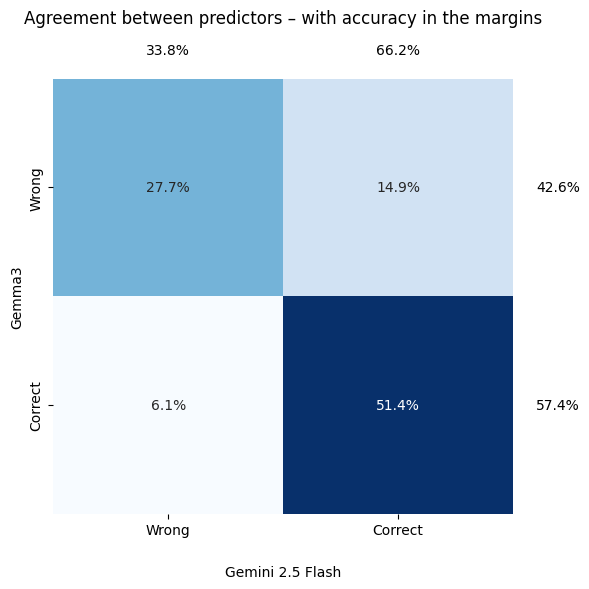

(148, 10)


In [151]:
# your data
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gemini 2.5 Flash', labelpad=20)
ax.set_ylabel('Gemma3')
ax.set_title('Agreement between predictors – with accuracy in the margins', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


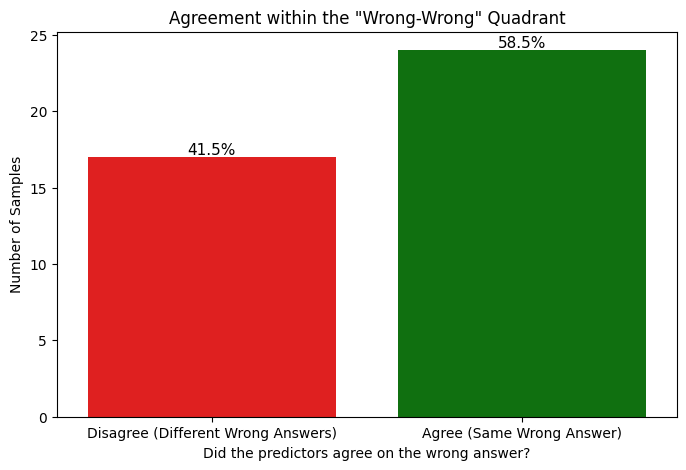

In [152]:
wrong_wrong_df = eval_df_all[
    (eval_df_all['text'] != eval_df_all['pred_text1']) &
    (eval_df_all['text'] != eval_df_all['pred_text2'])
].copy()

wrong_wrong_df['agreement_on_wrong'] = (
    wrong_wrong_df['pred_text1'] == wrong_wrong_df['pred_text2']
)

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=wrong_wrong_df,
    x='agreement_on_wrong',
    hue='agreement_on_wrong',
    palette=['Red', 'Green'],
    legend=False
)

plt.title('Agreement within the "Wrong-Wrong" Quadrant')
plt.ylabel('Number of Samples')
plt.xlabel('Did the predictors agree on the wrong answer?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree (Different Wrong Answers)', 'Agree (Same Wrong Answer)'])

# Add percentage annotations
total = len(wrong_wrong_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_115278/1012052540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


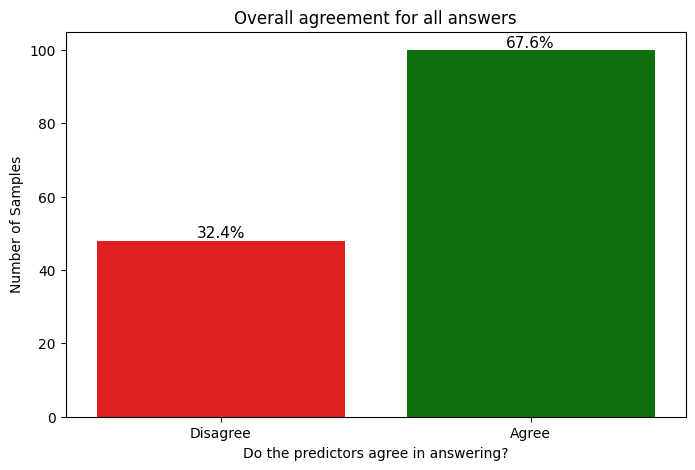

In [153]:
agreement_df = pd.DataFrame((eval_df_all['pred_text1'] == eval_df_all['pred_text2']), columns=['agreement'])

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=agreement_df,
    x='agreement',
    palette=['Red', 'Green']
)

plt.title('Overall agreement for all answers')
plt.ylabel('Number of Samples')
plt.xlabel('Do the predictors agree in answering?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree', 'Agree'])

# Add percentage annotations
total = len(agreement_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_115278/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_115278/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_115278/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_115278/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


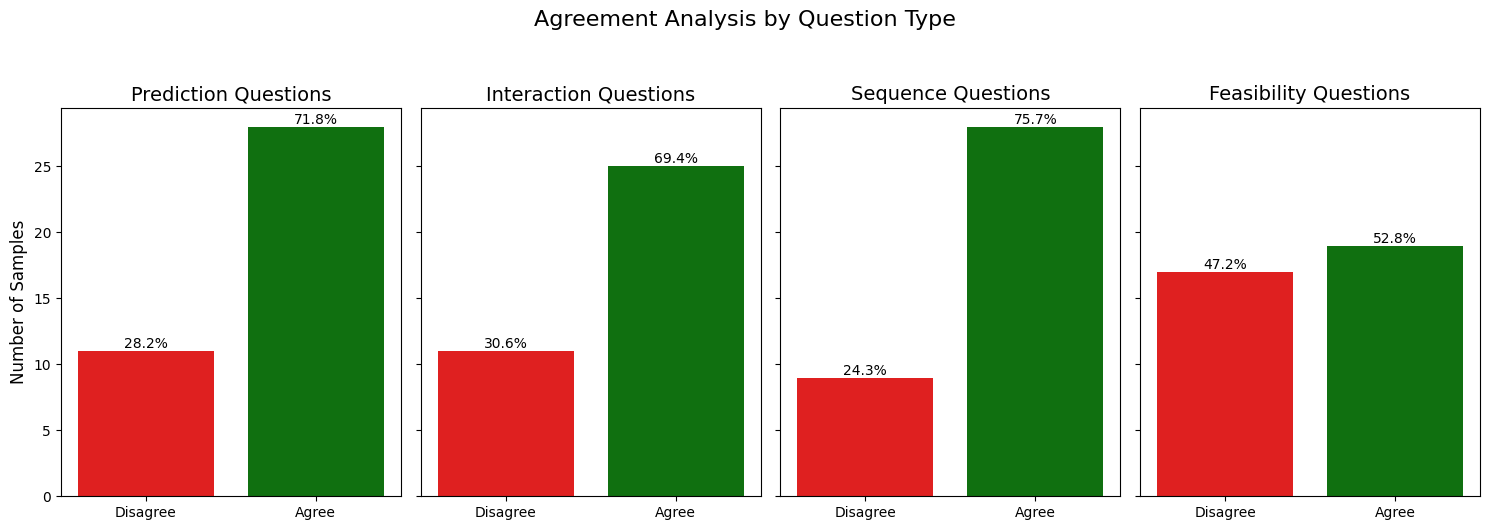

In [154]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Create agreement column in the copy
viz_df['agreement'] = viz_df['pred_text1'] == viz_df['pred_text2']

# Get unique question types
question_types = viz_df['question_type'].unique()
n_types = len(question_types)

# Create subplots
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)
fig.suptitle('Agreement Analysis by Question Type', fontsize=16, y=1.05)

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Create countplot
    ax = sns.countplot(
        data=subset,
        x='agreement',
        palette=['Red', 'Green'],
        ax=axes[i]
    )
    
    # Set title and labels
    ax.set_title(f'{qtype} Questions', fontsize=14)
    ax.set_xlabel('')
    if i == 0:
        ax.set_ylabel('Number of Samples', fontsize=12)
    
    # Set x-ticks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Disagree', 'Agree'])
    
    # Add percentage annotations
    total = len(subset)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# Experiment 2
### Comparing Gemini (2.5 flash) VQA on interactive vs batch mode

In [155]:
VQA_RESP_FILEPATH_INTERACTIVE = WORK_DIR / "notebooks/gemini_vqa_small200_20250722_15:44:00.jsonl" #Qwen2.5VL 1000 samples
VQA_RESP_FILEPATH_BATCH = WORK_DIR / "scripts/data/vqa_gemini_flash_full_chat_history.jsonl" #Qwen2.5VL GQA on Qwen SGG


In [156]:
# To extract the answers in the interactive mode I'm using the ollama format because I formatted
# the output structure myself when i was receiving the messages

interactive_pred_gg_df = rp.ans_extract(VQA_RESP_FILEPATH_INTERACTIVE, "gemma3", format="ollama")
batch_pred_gg_df = rp.ans_extract(VQA_RESP_FILEPATH_BATCH, "gemma3", format="gemini")


Total answers: 125
Answers following JSON template: 125
Percentage following JSON template: 100.00%
Answer with a valid alternative: 114
91.20% of the total

Invalid answers: 11


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {  "answer": "The video shows the person opening a door and walking into another room. Subsequently, in the new room, the person approaches a desk and picks up a flat, circular object, which they then bring to their mouth. None of the provided alternatives perfectly align with the visual evidence as *immediately* after opening the door, the person simply walks through. However, looking at the subsequent distinct action sequence in the video after the door is opened and the person moves to the next room, the person picks up an item from the desk. The item is a flat, circular disk, not explicitly a shoe, sandwich, paper/notebook, or another closet/cabinet. Given the provided choices and the action of taking an object and 

Total answers: 200
Answers following JSON template: 195
Percentage following JSON template: 97.50%
Answer with a valid alternative: 175
89.74% of the total

Invalid answers: 20


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [157]:
interactive_pred_gg_df = interactive_pred_gg_df[interactive_pred_gg_df['contains_answer']]
batch_pred_gg_df = batch_pred_gg_df[batch_pred_gg_df['contains_answer']]


In [158]:
interactive_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df1 = gt_df.join(
    interactive_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df1, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          33         81.82%  
Sequence             25         88.00%  
Prediction           32         75.00%  
Feasibility          24         41.67%  

Average              114        72.81%  


In [159]:
rp.print_ans_perc(eval_df1, gt_df)


Question type       Total      Answered 

Interaction          50         66.00%  
Sequence             50         50.00%  
Prediction           50         64.00%  
Feasibility          50         48.00%  
Overall              200        57.00%  


In [160]:
batch_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df2 = gt_df.join(
    batch_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df2, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          49         83.67%  
Sequence             44         84.09%  
Prediction           41         73.17%  
Feasibility          41         41.46%  

Average              175        71.43%  


In [161]:
rp.print_ans_perc(batch_pred_gg_df, gt_df)


Question type       Total      Answered 

Interaction          50         98.00%  
Sequence             50         88.00%  
Prediction           50         82.00%  
Feasibility          50         82.00%  
Overall              200        87.50%  


In [162]:
interactive_pred_gg_df.rename(columns={'pred_text': 'pred_text1'}, inplace=True)
batch_pred_gg_df.rename(columns={'pred_text': 'pred_text2'}, inplace=True)
eval_df_all = gt_df.join(
    interactive_pred_gg_df[['pred_text1']],
    how='inner'
).join(
    batch_pred_gg_df[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
Prediction_T1_2102,What will the person do next?,close the refrigerator.,close the refrigerator.,close the refrigerator.
Interaction_T4_3931,What did the person do while they were sitting...,opened the closet/cabinet.,opened the closet/cabinet.,opened the closet/cabinet.
Interaction_T1_9123,Which object was opened by the person?,the refrigerator.,the refrigerator.,the refrigerator.
Prediction_T1_2737,What will the person do next?,open the laptop.,open the laptop.,take the phone/camera.
Prediction_T3_495,Which object would the person take next?,the clothes.,the bag.,the bag.
...,...,...,...,...
Interaction_T1_6336,Which object was put down by the person?,the laptop.,the laptop.,the laptop.
Sequence_T6_3033,What did the person do to the cup/glass/bottle...,took.,took.,took.
Interaction_T3_2531,What did the person do while they were holding...,put down the bag.,opened the bag.,opened the bag.
Sequence_T2_521,Which object did the person take before they h...,the blanket.,the blanket.,the blanket.


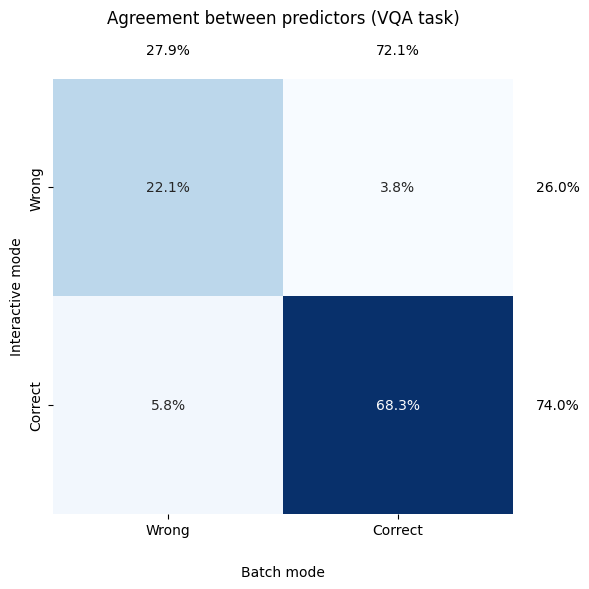

(104, 10)


In [163]:
# your data
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Batch mode', labelpad=20)
ax.set_ylabel('Interactive mode')
ax.set_title('Agreement between predictors (VQA task)', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


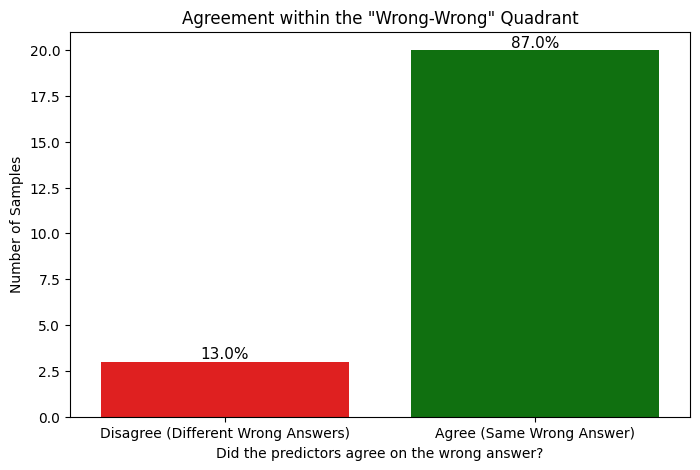

In [164]:
wrong_wrong_df = eval_df_all[
    (eval_df_all['text'] != eval_df_all['pred_text1']) &
    (eval_df_all['text'] != eval_df_all['pred_text2'])
].copy()

wrong_wrong_df['agreement_on_wrong'] = (
    wrong_wrong_df['pred_text1'] == wrong_wrong_df['pred_text2']
)

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=wrong_wrong_df,
    x='agreement_on_wrong',
    hue='agreement_on_wrong',
    palette=['Red', 'Green'],
    legend=False
)

plt.title('Agreement within the "Wrong-Wrong" Quadrant')
plt.ylabel('Number of Samples')
plt.xlabel('Did the predictors agree on the wrong answer?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree (Different Wrong Answers)', 'Agree (Same Wrong Answer)'])

# Add percentage annotations
total = len(wrong_wrong_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_115278/1012052540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


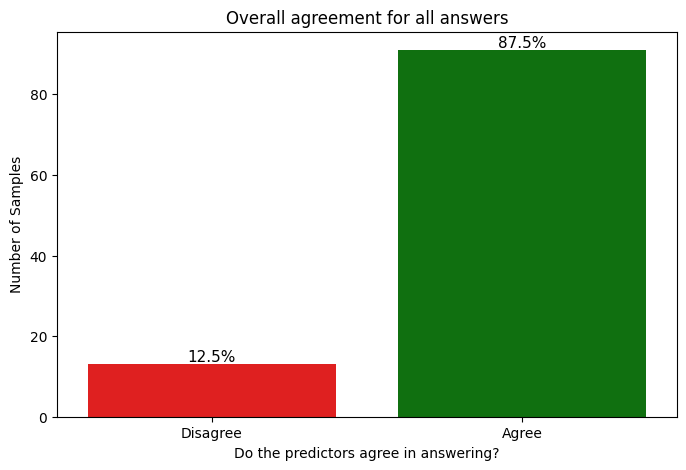

In [165]:
agreement_df = pd.DataFrame((eval_df_all['pred_text1'] == eval_df_all['pred_text2']), columns=['agreement'])

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=agreement_df,
    x='agreement',
    palette=['Red', 'Green']
)

plt.title('Overall agreement for all answers')
plt.ylabel('Number of Samples')
plt.xlabel('Do the predictors agree in answering?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree', 'Agree'])

# Add percentage annotations
total = len(agreement_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_115278/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_115278/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_115278/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_115278/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


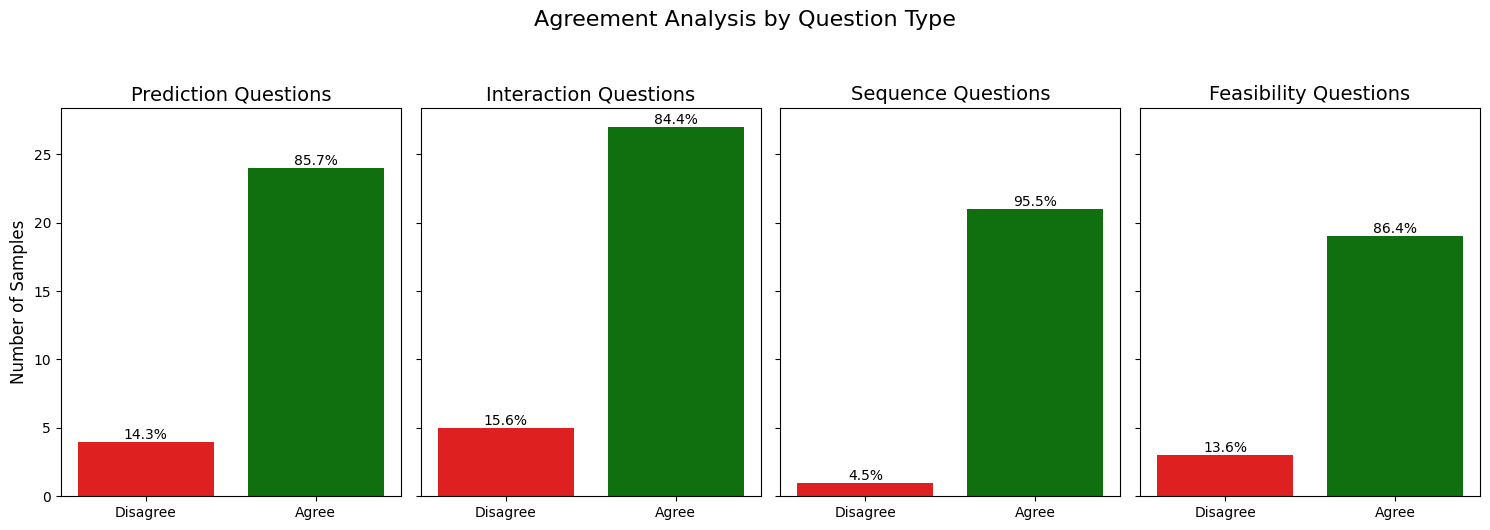

In [166]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Create agreement column in the copy
viz_df['agreement'] = viz_df['pred_text1'] == viz_df['pred_text2']

# Get unique question types
question_types = viz_df['question_type'].unique()
n_types = len(question_types)

# Create subplots
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)
fig.suptitle('Agreement Analysis by Question Type', fontsize=16, y=1.05)

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Create countplot
    ax = sns.countplot(
        data=subset,
        x='agreement',
        palette=['Red', 'Green'],
        ax=axes[i]
    )
    
    # Set title and labels
    ax.set_title(f'{qtype} Questions', fontsize=14)
    ax.set_xlabel('')
    if i == 0:
        ax.set_ylabel('Number of Samples', fontsize=12)
    
    # Set x-ticks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Disagree', 'Agree'])
    
    # Add percentage annotations
    total = len(subset)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
